# Доповідь. Функції активації та оптимізатори нейронних мереж
**Тема 4, заняття 8** · Жвавий І.

**Що показує приклад:**
1. Як виглядають основні функції активації (sigmoid, tanh, ReLU) та їхні похідні.
2. Як вибір активації впливає на навчання глибокої мережі (згасання градієнта).
3. Як різні оптимізатори (SGD, SGD з моментом, RMSprop, Adam) зменшують помилку за однакову кількість епох.

**Дані:** `make_classification`, 1000 об'єктів, 3 класи (ті самі параметри, що в практичній 4.8, N = 1).

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
%config InlineBackend.figure_formats = ["jpeg"]
plt.rcParams["figure.dpi"] = 80
sns.set_theme(style="ticks")
SEED = 1
X, y = make_classification(n_samples=1000, n_features=10, n_informative=6, n_redundant=2, n_classes=3,
                           n_clusters_per_class=2, class_sep=0.9, flip_y=0.02, random_state=SEED)
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)
sc = StandardScaler().fit(X_tr); X_tr, X_va = sc.transform(X_tr), sc.transform(X_va)
print("train / validation:", len(X_tr), len(X_va))

I0000 00:00:1791384997.255797    4063 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791384998.841820    4063 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


train / validation: 750 250


## 1. Функції активації та їхні похідні
Під час зворотного поширення помилки градієнт множиться на похідну активації в кожному шарі. Похідна sigmoid не перевищує 0.25, tanh не перевищує 1, а у ReLU вона дорівнює 1 для всіх додатних входів.

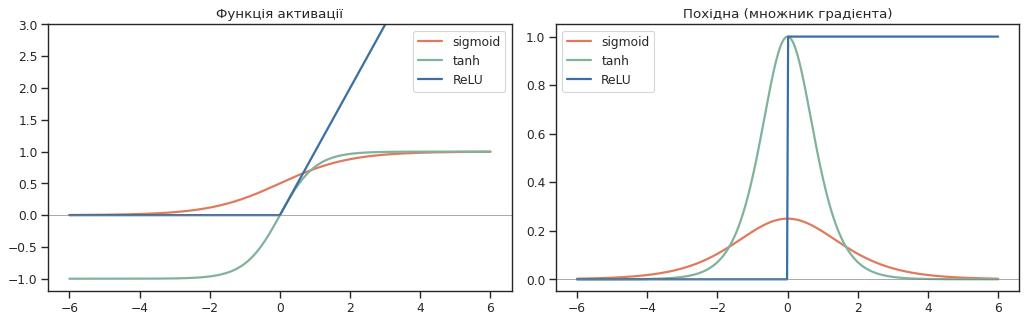

Максимум похідної: sigmoid = 0.25, tanh = 1.0, ReLU = 1.0
Після 6 шарів sigmoid градієнт зменшується щонайменше в 4096 разів


In [2]:
z = np.linspace(-6, 6, 400)
sig = 1 / (1 + np.exp(-z)); th = np.tanh(z); relu = np.maximum(0, z)
funcs = {"sigmoid": (sig, sig * (1 - sig)), "tanh": (th, 1 - th ** 2), "ReLU": (relu, (z > 0).astype(float))}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for (name, (f, d)), col in zip(funcs.items(), ["#e07a5f", "#81b29a", "#3a6ea5"]):
    axes[0].plot(z, f, label=name, color=col, lw=2); axes[1].plot(z, d, label=name, color=col, lw=2)
axes[0].set_ylim(-1.2, 3); axes[0].set_title("Функція активації"); axes[1].set_title("Похідна (множник градієнта)")
for a in axes: a.axhline(0, color="gray", lw=0.6); a.legend()
plt.tight_layout(); plt.show()
print("Максимум похідної: sigmoid = 0.25, tanh = 1.0, ReLU = 1.0")
print("Після 6 шарів sigmoid градієнт зменшується щонайменше в", round(1 / 0.25 ** 6), "разів")

## 2. Вплив активації на навчання глибокої мережі
Однакова мережа з **6 прихованими шарами по 32 нейрони**, однаковий оптимізатор (SGD, крок 0.05), 60 епох. Змінюється лише функція активації у прихованих шарах.

In [3]:
def deep_net(act, seed=SEED):
    keras.utils.set_random_seed(seed)
    m = keras.Sequential([keras.Input(shape=(10,))] + [layers.Dense(32, activation=act) for _ in range(6)] +
                         [layers.Dense(3, activation="softmax")])
    m.compile(optimizer=keras.optimizers.SGD(0.05), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

def first_layer_grad(m):
    xs = tf.constant(X_tr, dtype=tf.float32)
    vars_ = [v.value for v in m.trainable_weights]
    with tf.GradientTape() as tape:
        tape.watch(vars_)
        loss = tf.reduce_mean(keras.losses.sparse_categorical_crossentropy(y_tr, m(xs, training=False)))
    g = tape.gradient(loss, vars_)
    return float(tf.reduce_mean(tf.abs(g[0]))), float(tf.reduce_mean(tf.abs(g[-2])))

act_hist, act_rows = {}, []
for act in ["sigmoid", "tanh", "relu"]:
    m = deep_net(act)
    g_first, g_last = first_layer_grad(m)
    h = m.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=60, batch_size=32, verbose=0)
    act_hist[act] = h.history
    act_rows.append({"активація": act, "градієнт 1-го шару": g_first, "градієнт вихідного шару": g_last,
                     "val accuracy (60 епох)": h.history["val_accuracy"][-1]})
act_tab = pd.DataFrame(act_rows).set_index("активація")
act_tab.style.format({"градієнт 1-го шару": "{:.2e}", "градієнт вихідного шару": "{:.2e}", "val accuracy (60 епох)": "{:.3f}"})

,градієнт 1-го шару,градієнт вихідного шару,val accuracy (60 епох)
активація,,,
sigmoid,5.76e-06,3.10e-02,0.328
tanh,1.71e-02,2.34e-02,0.852
relu,2.24e-03,2.28e-03,0.832


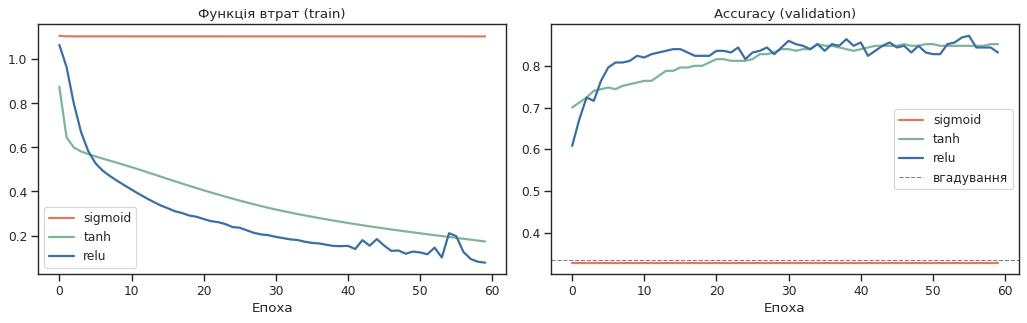

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for act, col in zip(act_hist, ["#e07a5f", "#81b29a", "#3a6ea5"]):
    axes[0].plot(act_hist[act]["loss"], label=act, color=col, lw=2)
    axes[1].plot(act_hist[act]["val_accuracy"], label=act, color=col, lw=2)
axes[0].set_title("Функція втрат (train)"); axes[1].set_title("Accuracy (validation)")
axes[1].axhline(1 / 3, color="gray", ls="--", lw=1, label="вгадування")
for a in axes: a.set_xlabel("Епоха"); a.legend()
plt.tight_layout(); plt.show()

## 3. Порівняння оптимізаторів
Мережа `10 → 32 → 16 → 3` з активацією ReLU, 60 епох, batch 32. Змінюється лише оптимізатор. Для кожного варіанта 3 запуски з різним початковим seed.

In [5]:
def small_net(opt, seed):
    keras.utils.set_random_seed(seed)
    m = keras.Sequential([keras.Input(shape=(10,)), layers.Dense(32, activation="relu"),
                          layers.Dense(16, activation="relu"), layers.Dense(3, activation="softmax")])
    m.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

optims = {"SGD (крок 0.01)": lambda: keras.optimizers.SGD(0.01),
          "SGD + момент 0.9": lambda: keras.optimizers.SGD(0.01, momentum=0.9),
          "RMSprop": lambda: keras.optimizers.RMSprop(0.001),
          "Adam": lambda: keras.optimizers.Adam(0.001)}
opt_hist, opt_rows = {}, []
for name, mk in optims.items():
    runs = []
    for s in range(3):
        h = small_net(mk(), 10 + s).fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=60, batch_size=32, verbose=0).history
        runs.append(h)
    loss = np.mean([r["loss"] for r in runs], axis=0); vacc = np.mean([r["val_accuracy"] for r in runs], axis=0)
    opt_hist[name] = (loss, vacc)
    reach = next((i + 1 for i, v in enumerate(vacc) if v >= 0.8), None)
    opt_rows.append({"оптимізатор": name, "train loss (60 еп.)": loss[-1], "val accuracy (60 еп.)": vacc[-1],
                     "епох до val acc ≥ 0.80": reach if reach else "не досягнуто"})
opt_tab = pd.DataFrame(opt_rows).set_index("оптимізатор")
opt_tab.round(3)

,train loss (60 еп.),val accuracy (60 еп.),епох до val acc ≥ 0.80
оптимізатор,,,
SGD (крок 0.01),0.443,0.788,не досягнуто
SGD + момент 0.9,0.158,0.832,9
RMSprop,0.259,0.836,23
Adam,0.240,0.844,21


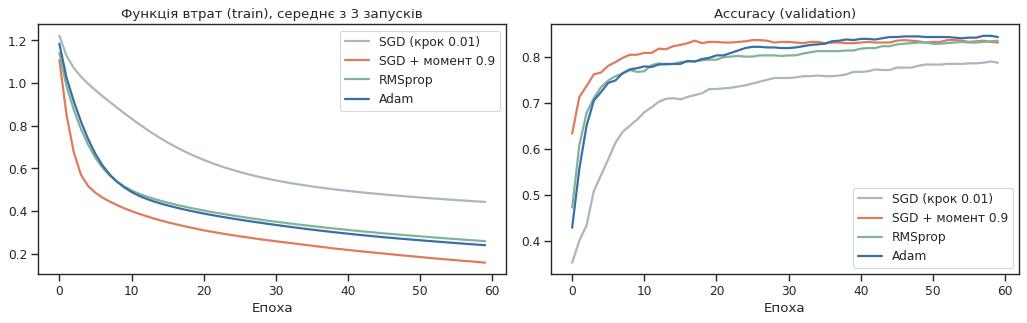

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for (name, (loss, vacc)), col in zip(opt_hist.items(), ["#adb5bd", "#e07a5f", "#81b29a", "#3a6ea5"]):
    axes[0].plot(loss, label=name, color=col, lw=2); axes[1].plot(vacc, label=name, color=col, lw=2)
axes[0].set_title("Функція втрат (train), середнє з 3 запусків"); axes[1].set_title("Accuracy (validation)")
for a in axes: a.set_xlabel("Епоха"); a.legend()
plt.tight_layout(); plt.show()

## 4. Висновки

**Функції активації.** У мережі з 6 прихованими шарами та активацією sigmoid середній градієнт першого шару (≈ 6·10⁻⁶) приблизно в 5000 разів менший, ніж у вихідного шару (≈ 3·10⁻²). Ранні шари фактично не навчаються, функція втрат за 60 епох не змінилася, а точність залишилася на рівні вгадування (0.33). Це і є проблема згасання градієнта. З tanh та ReLU та сама мережа навчилася до точності 0.85 і 0.83. Тому в прихованих шарах сучасних мереж зазвичай використовують ReLU, а sigmoid та softmax залишають для вихідного шару, де потрібні ймовірності.

**Оптимізатори.** Звичайний SGD із кроком 0.01 за 60 епох не досяг точності 0.80 (0.79 наприкінці). Додавання моменту 0.9 прискорило навчання найбільше: точність 0.80 досягнуто вже на 9-й епосі. Адаптивні методи RMSprop та Adam досягли 0.80 за 21–23 епохи і дали найвищу кінцеву точність (0.84 у Adam). Adam зручний тим, що добре працює зі стандартним кроком 0.001 без додаткового налаштування, тому його найчастіше обирають за замовчуванням.

**Практичне правило:** ReLU у прихованих шарах, softmax (класифікація) або лінійний вихід (регресія) на виході, оптимізатор Adam як стартовий варіант.